In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from warnings import filterwarnings
filterwarnings('ignore')

In [3]:
df = pd.read_csv(r"C:\Users\user\Downloads\Apple Pricing dataset\apple_products_pricing_2020_2026.csv")
df.head()

,Date,Platform,Product_Category,Model_Name,Condition,Launch_Price_USD,Launch_Price_INR,Current_Price_USD,Current_Price_INR,Discount_Pct,Sale_Event,Stock_Status,Rating,Reviews_Count
0,2020-09-19,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,435.81,43322.41,-1.6,NaN,In Stock,4.7,40
1,2020-09-20,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,436.49,42320.43,-1.7,NaN,Out of Stock,4.6,84
2,2020-09-23,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,422.73,40879.36,1.5,NaN,In Stock,4.4,110
3,2020-09-23,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,425.00,42008.70,0.9,NaN,In Stock,4.8,111
4,2020-09-24,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,436.22,41984.28,-1.7,NaN,In Stock,4.7,35


### EDA

#### 1.Data Understanding

In [4]:
df.shape

(80000, 14)

In [5]:
df.dtypes

Date                  object
Platform              object
Product_Category      object
Model_Name            object
Condition             object
Launch_Price_USD       int64
Launch_Price_INR       int64
Current_Price_USD    float64
Current_Price_INR    float64
Discount_Pct         float64
Sale_Event            object
Stock_Status          object
Rating               float64
Reviews_Count          int64
dtype: object

In [6]:
df.columns

Index(['Date', 'Platform', 'Product_Category', 'Model_Name', 'Condition',
       'Launch_Price_USD', 'Launch_Price_INR', 'Current_Price_USD',
       'Current_Price_INR', 'Discount_Pct', 'Sale_Event', 'Stock_Status',
       'Rating', 'Reviews_Count'],
      dtype='object')

In [7]:
df.describe()

,Launch_Price_USD,Launch_Price_INR,Current_Price_USD,Current_Price_INR,Discount_Pct,Rating,Reviews_Count
count,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000
mean,963.959125,94467.994250,782.769855,74628.342439,21.418826,4.450099,2405.995925
std,470.086413,46068.468464,461.673970,45117.872172,16.697310,0.269782,1973.630852
min,329.000000,32242.000000,109.930000,9157.680000,-2.000000,3.800000,10.000000
25%,599.000000,58702.000000,432.930000,41686.835000,6.700000,4.300000,896.000000
50%,799.000000,78302.000000,699.740000,67324.020000,21.300000,4.400000,1893.500000
75%,1199.000000,117502.000000,989.112500,96568.117500,36.800000,4.700000,3383.000000
max,1999.000000,195902.000000,2038.970000,203668.710000,73.100000,4.900000,11526.000000


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               80000 non-null  object 
 1   Platform           80000 non-null  object 
 2   Product_Category   80000 non-null  object 
 3   Model_Name         80000 non-null  object 
 4   Condition          80000 non-null  object 
 5   Launch_Price_USD   80000 non-null  int64  
 6   Launch_Price_INR   80000 non-null  int64  
 7   Current_Price_USD  80000 non-null  float64
 8   Current_Price_INR  80000 non-null  float64
 9   Discount_Pct       80000 non-null  float64
 10  Sale_Event         6649 non-null   object 
 11  Stock_Status       80000 non-null  object 
 12  Rating             80000 non-null  float64
 13  Reviews_Count      80000 non-null  int64  
dtypes: float64(4), int64(3), object(7)
memory usage: 8.5+ MB


In [9]:
df.isnull().sum() 

Date                     0
Platform                 0
Product_Category         0
Model_Name               0
Condition                0
Launch_Price_USD         0
Launch_Price_INR         0
Current_Price_USD        0
Current_Price_INR        0
Discount_Pct             0
Sale_Event           73351
Stock_Status             0
Rating                   0
Reviews_Count            0
dtype: int64

In [10]:
df.Sale_Event.unique()

array([nan, 'Big Billion Days', 'Great Indian Festival', 'Black Friday',
       'Prime Day'], dtype=object)

In [11]:
df[df.Sale_Event == 'Big Billion Days']

,Date,Platform,Product_Category,Model_Name,Condition,Launch_Price_USD,Launch_Price_INR,Current_Price_USD,Current_Price_INR,Discount_Pct,Sale_Event,Stock_Status,Rating,Reviews_Count
8,2020-10-01,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,323.84,31855.01,24.5,Big Billion Days,In Stock,4.7,95
12,2020-10-02,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,348.70,34771.74,18.7,Big Billion Days,In Stock,4.6,71
13,2020-10-03,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,324.80,32134.64,24.3,Big Billion Days,In Stock,4.9,62
17,2020-10-06,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,354.95,34964.38,17.3,Big Billion Days,In Stock,4.7,176
18,2020-10-07,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,348.33,34539.69,18.8,Big Billion Days,In Stock,4.7,140
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59212,2025-10-15,Flipkart,iPhone,iPhone 17 128GB,Renewed/Refurbished,849,83202,568.97,48961.55,33.0,Big Billion Days,In Stock,4.1,99
59213,2025-10-15,Flipkart,iPhone,iPhone 17 128GB,New,849,83202,741.65,72245.87,12.6,Big Billion Days,Out of Stock,4.7,162
59214,2025-10-15,Flipkart,iPhone,iPhone 17 128GB,New,849,83202,762.62,75674.57,10.2,Big Billion Days,In Stock,4.5,65
59215,2025-10-15,Flipkart,iPhone,iPhone 17 128GB,New,849,83202,737.65,72832.84,13.1,Big Billion Days,Out of Stock,4.7,234


In [12]:
df[df.Sale_Event == 'Great Indian Festival']

,Date,Platform,Product_Category,Model_Name,Condition,Launch_Price_USD,Launch_Price_INR,Current_Price_USD,Current_Price_INR,Discount_Pct,Sale_Event,Stock_Status,Rating,Reviews_Count
9,2020-10-01,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,390.51,38757.36,9.0,Great Indian Festival,In Stock,4.9,133
10,2020-10-01,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,385.37,37753.37,10.2,Great Indian Festival,In Stock,4.5,57
11,2020-10-01,Amazon,Watch,Apple Watch Series 6 (44mm),Renewed/Refurbished,429,42042,274.88,23070.56,35.9,Great Indian Festival,In Stock,4.5,99
14,2020-10-04,Amazon,Watch,Apple Watch Series 6 (44mm),Renewed/Refurbished,429,42042,265.10,22614.35,38.2,Great Indian Festival,Low Stock,4.4,112
15,2020-10-06,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,348.69,33665.07,18.7,Great Indian Festival,Out of Stock,4.4,127
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59205,2025-10-15,Amazon,iPhone,iPhone 16 Pro 256GB,New,1099,107702,738.42,71089.74,32.8,Great Indian Festival,In Stock,4.2,1949
59206,2025-10-15,Amazon,iPhone,iPhone 16 Pro 256GB,New,1099,107702,760.71,74173.74,30.8,Great Indian Festival,Out of Stock,4.5,2014
59208,2025-10-15,Amazon,iPhone,iPhone 17 128GB,New,849,83202,698.38,68228.74,17.7,Great Indian Festival,In Stock,4.3,178
59211,2025-10-15,Amazon,iPhone,iPhone 17 128GB,New,849,83202,690.00,68766.44,18.7,Great Indian Festival,In Stock,4.4,209


In [13]:
df[df.Sale_Event == 'Black Friday']

,Date,Platform,Product_Category,Model_Name,Condition,Launch_Price_USD,Launch_Price_INR,Current_Price_USD,Current_Price_INR,Discount_Pct,Sale_Event,Stock_Status,Rating,Reviews_Count
179,2020-11-20,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,367.62,35995.89,14.3,Black Friday,In Stock,4.5,175
180,2020-11-20,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,398.64,38605.09,7.1,Black Friday,In Stock,4.3,253
181,2020-11-20,Amazon,Mac,MacBook Air M1 256GB,New,999,97902,918.33,90904.71,8.1,Black Friday,Out of Stock,4.4,100
182,2020-11-20,Flipkart,Mac,MacBook Air M1 256GB,New,999,97902,846.15,81655.07,15.3,Black Friday,In Stock,4.6,45
183,2020-11-20,Amazon,iPad,iPad Air (4th Gen) 64GB,New,599,58702,531.22,52940.95,11.3,Black Friday,In Stock,4.2,137
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62491,2025-11-30,Flipkart,iPhone,iPhone 17 128GB,New,849,83202,768.75,74192.48,9.5,Black Friday,In Stock,4.8,245
62492,2025-11-30,Amazon,iPhone,iPhone 17 128GB,Renewed/Refurbished,849,83202,567.51,47732.26,33.2,Black Friday,In Stock,4.2,426
62493,2025-11-30,Amazon,iPhone,iPhone 17 128GB,New,849,83202,756.50,74556.53,10.9,Black Friday,In Stock,4.6,398
62494,2025-11-30,Flipkart,iPhone,iPhone 17 128GB,New,849,83202,719.27,71493.21,15.3,Black Friday,Out of Stock,4.3,194


In [14]:
df[df.Sale_Event == 'Prime Day']


,Date,Platform,Product_Category,Model_Name,Condition,Launch_Price_USD,Launch_Price_INR,Current_Price_USD,Current_Price_INR,Discount_Pct,Sale_Event,Stock_Status,Rating,Reviews_Count
1771,2021-07-10,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,398.48,38507.41,7.1,Prime Day,In Stock,4.9,1025
1776,2021-07-10,Amazon,iPad,iPad Air (4th Gen) 64GB,Renewed/Refurbished,599,58702,430.46,36241.98,28.1,Prime Day,Out of Stock,4.1,1104
1777,2021-07-10,Amazon,iPad,iPad Pro 11-inch (M1) 128GB,Renewed/Refurbished,799,78302,586.60,49028.52,26.6,Prime Day,Out of Stock,4.2,268
1779,2021-07-10,Amazon,iPad,iPad Pro 11-inch (M1) 128GB,New,799,78302,705.93,68791.31,11.6,Prime Day,In Stock,4.8,164
1781,2021-07-10,Amazon,iPad,iPad Pro 11-inch (M1) 128GB,New,799,78302,701.41,68055.57,12.2,Prime Day,In Stock,4.2,127
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79028,2026-07-18,Amazon,iPhone,iPhone 15 128GB,Renewed/Refurbished,799,78302,368.79,30776.70,53.8,Prime Day,Out of Stock,4.3,5354
79029,2026-07-18,Amazon,iPhone,iPhone 15 128GB,Renewed/Refurbished,799,78302,364.15,30973.24,54.4,Prime Day,In Stock,4.3,3422
79030,2026-07-18,Amazon,iPhone,iPhone 15 128GB,Renewed/Refurbished,799,78302,394.02,33948.86,50.7,Prime Day,In Stock,4.2,1467
79035,2026-07-18,Amazon,iPhone,iPhone 17 128GB,New,849,83202,726.87,72598.21,14.4,Prime Day,Out of Stock,4.6,1348


In [15]:
df.Sale_Event.isnull().sum()

np.int64(73351)

In [16]:
df[df.duplicated()]

,Date,Platform,Product_Category,Model_Name,Condition,Launch_Price_USD,Launch_Price_INR,Current_Price_USD,Current_Price_INR,Discount_Pct,Sale_Event,Stock_Status,Rating,Reviews_Count


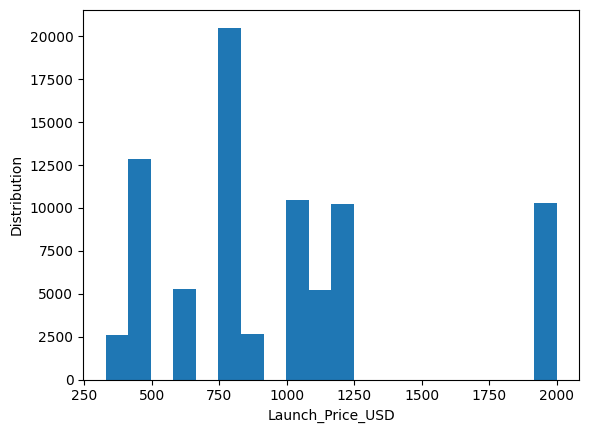

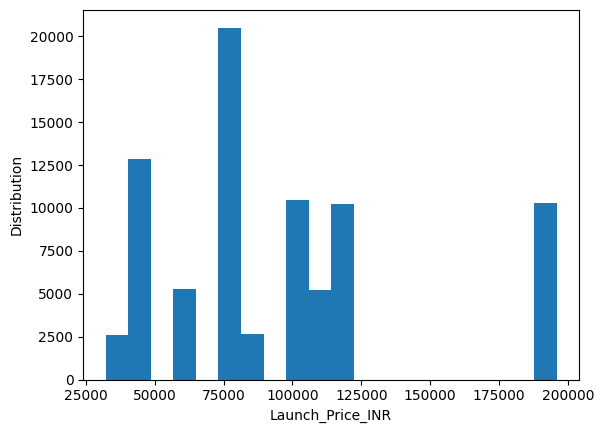

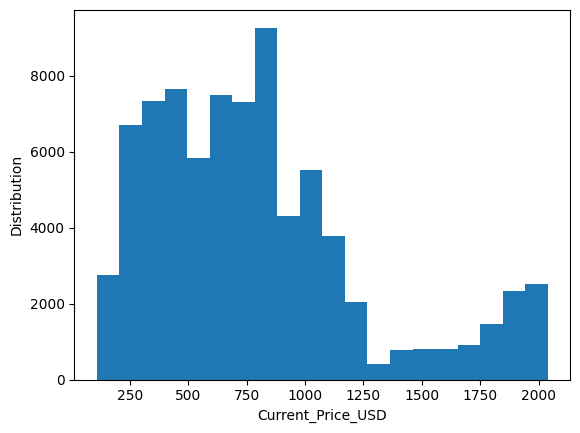

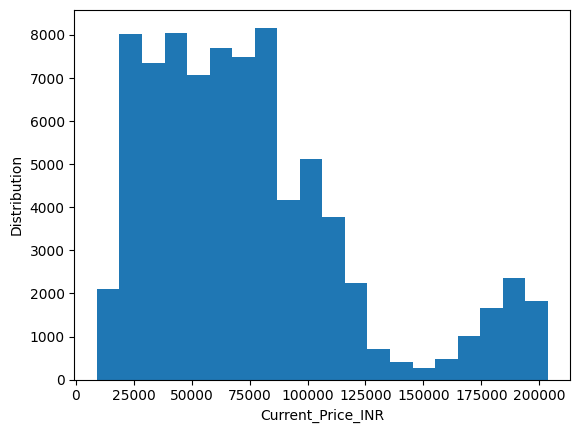

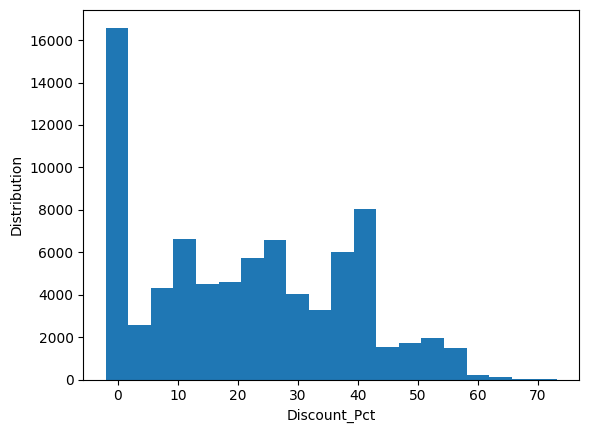

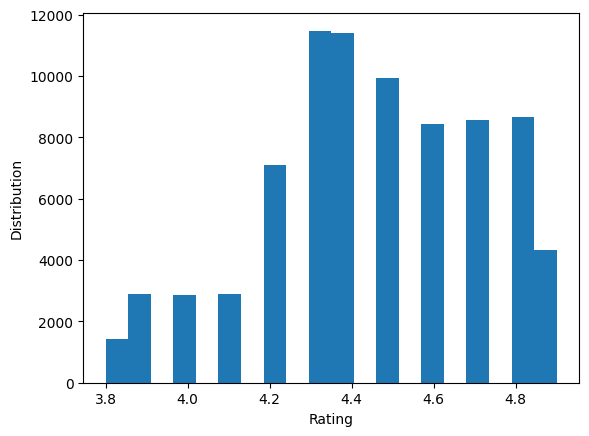

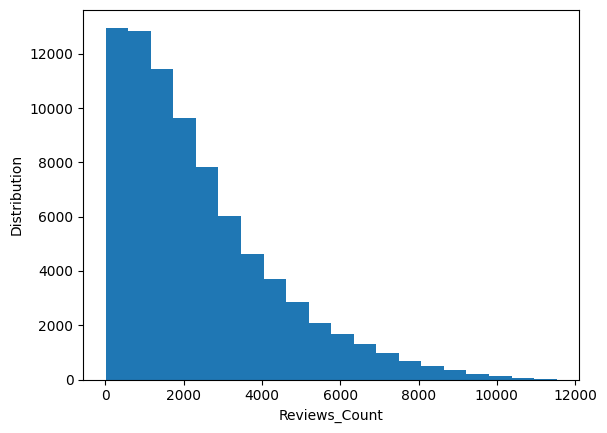

In [17]:
#univariate analysis
num_cols = df.select_dtypes(include='number').columns

for col in num_cols:
    plt.hist(df[col], bins = 20)
    plt.xlabel(col)
    plt.ylabel("Distribution")
    plt.show()


In [18]:
cat_cols = df.select_dtypes(include = 'object').columns

for col in cat_cols:
    print(df[col].value_counts(),'\n')

Date
2025-06-11    95
2026-06-20    93
2026-05-18    92
2026-01-07    91
2026-04-20    90
              ..
2020-10-09     1
2020-10-16     1
2020-10-21     1
2020-10-22     1
2020-09-19     1
Name: count, Length: 2130, dtype: int64 

Platform
Flipkart    40043
Amazon      39957
Name: count, dtype: int64 

Product_Category
iPhone    28589
Mac       18020
Watch     17865
iPad      15526
Name: count, dtype: int64 

Model_Name
iPhone 14 Pro 128GB                 2734
iPad Air (4th Gen) 64GB             2677
iPad Pro 11-inch (M1) 128GB         2661
iPhone 17 128GB                     2652
iPhone 16 Pro 256GB                 2635
MacBook Pro 14-inch M4 Pro 512GB    2623
MacBook Air M2 256GB                2610
Apple Watch Series 8 (45mm)         2606
iPhone 13 128GB                     2605
iPhone 12 Pro 128GB                 2604
iPhone 15 Pro Max 256GB             2603
iPhone 15 128GB                     2602
Apple Watch Series 7 (45mm)         2600
MacBook Air M3 256GB                2589

In [19]:
df.Date = pd.to_datetime(df.Date)

In [20]:
df.dtypes

Date                 datetime64[ns]
Platform                     object
Product_Category             object
Model_Name                   object
Condition                    object
Launch_Price_USD              int64
Launch_Price_INR              int64
Current_Price_USD           float64
Current_Price_INR           float64
Discount_Pct                float64
Sale_Event                   object
Stock_Status                 object
Rating                      float64
Reviews_Count                 int64
dtype: object

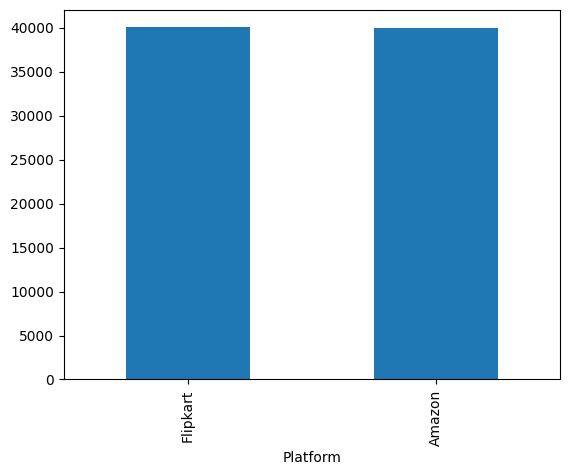

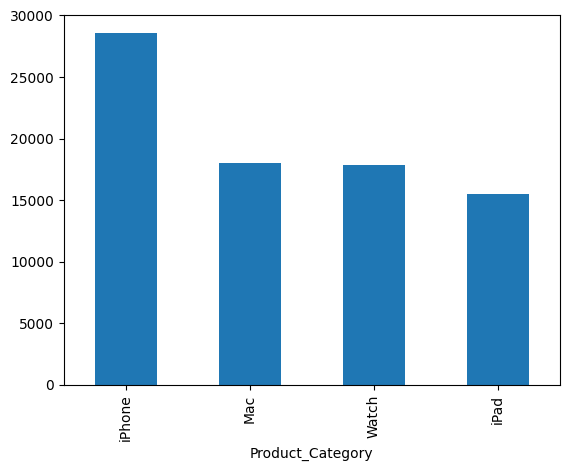

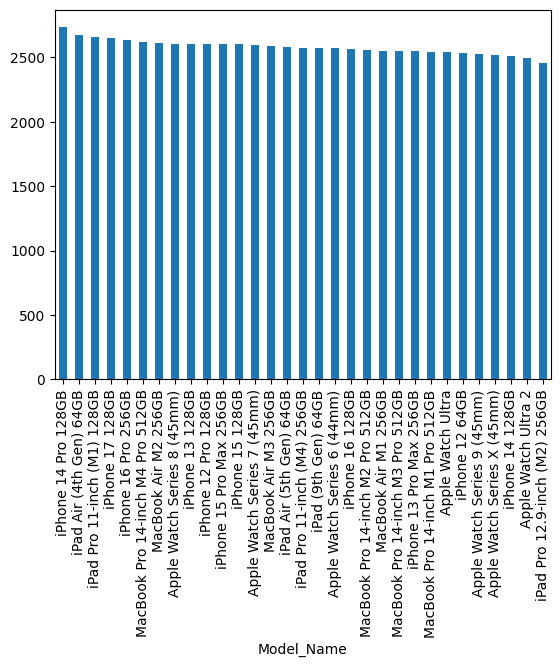

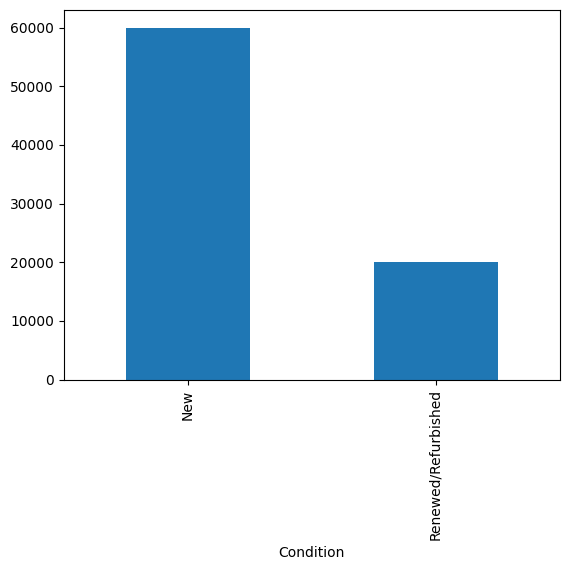

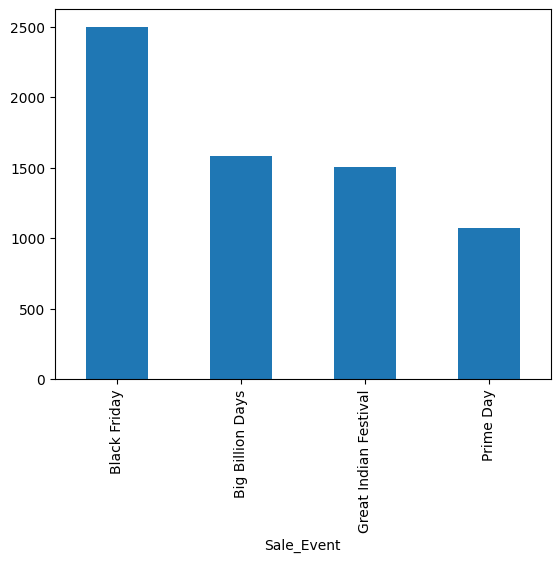

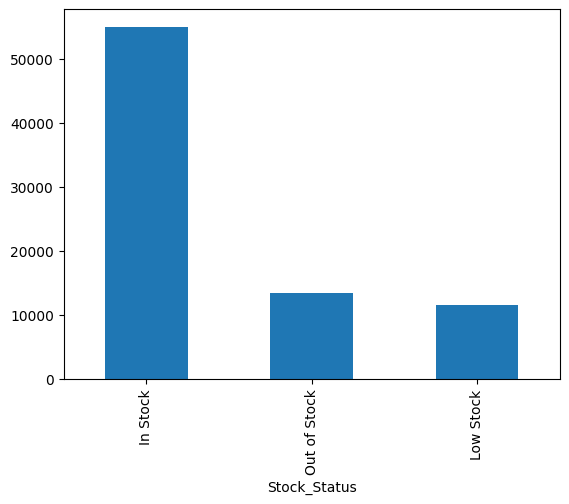

In [21]:
for col in ['Platform', 'Product_Category','Model_Name','Condition','Sale_Event','Stock_Status']:
    df[col].value_counts().plot(kind = 'bar')
    plt.show()

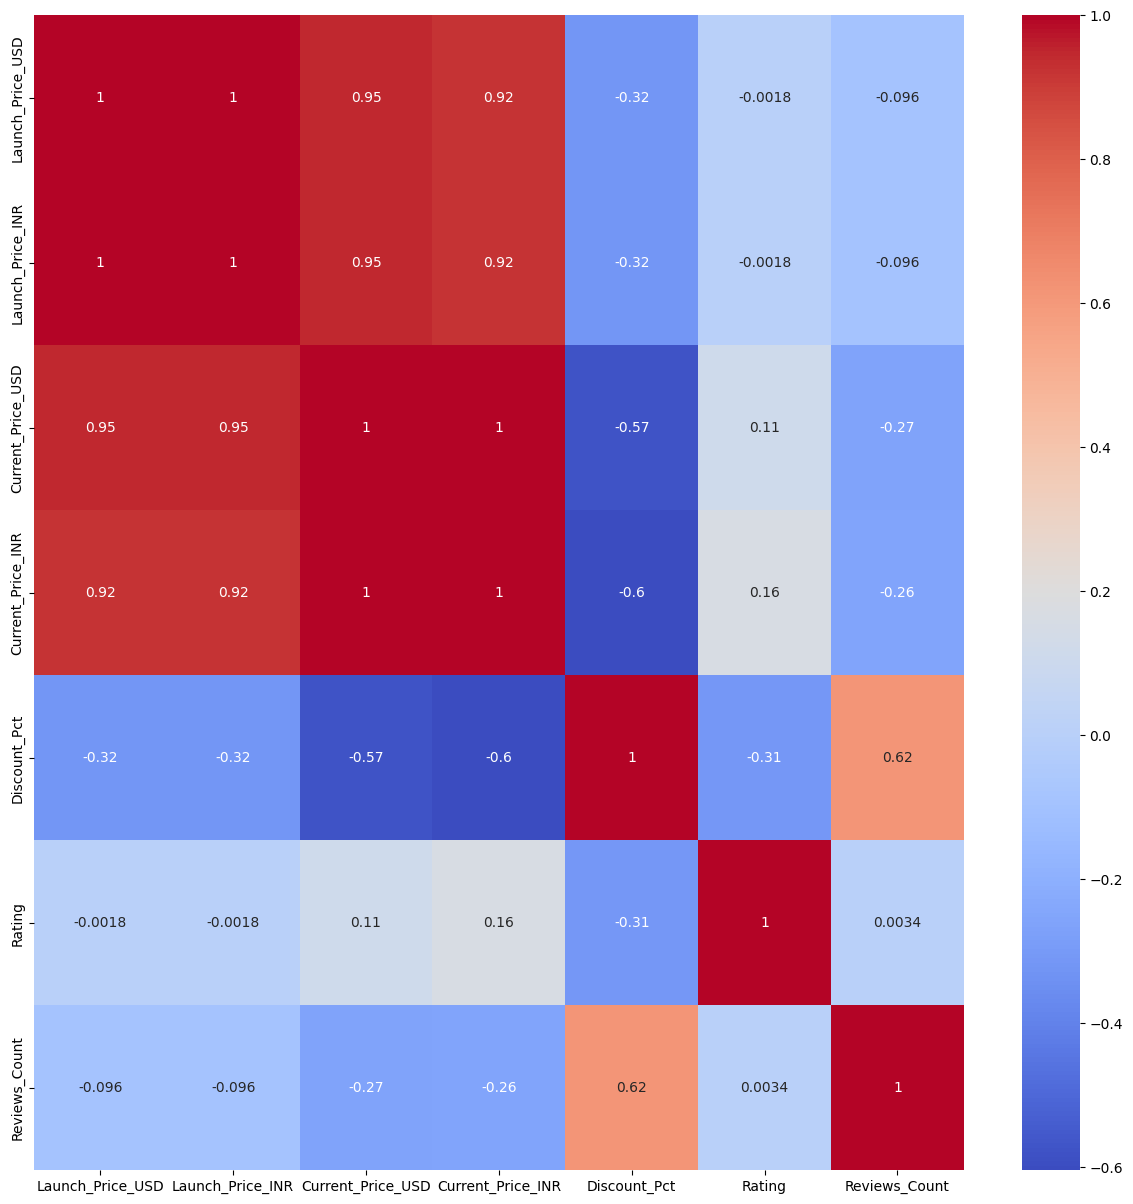

In [22]:
#Bivariate analysis
corr = df.select_dtypes(include = 'number').corr()

plt.figure(figsize=(15, 15))
sns.heatmap(corr, annot = True, cmap = 'coolwarm')
plt.show()

In [23]:
df.head()

,Date,Platform,Product_Category,Model_Name,Condition,Launch_Price_USD,Launch_Price_INR,Current_Price_USD,Current_Price_INR,Discount_Pct,Sale_Event,Stock_Status,Rating,Reviews_Count
0,2020-09-19,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,435.81,43322.41,-1.6,NaN,In Stock,4.7,40
1,2020-09-20,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,436.49,42320.43,-1.7,NaN,Out of Stock,4.6,84
2,2020-09-23,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,422.73,40879.36,1.5,NaN,In Stock,4.4,110
3,2020-09-23,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,425.00,42008.70,0.9,NaN,In Stock,4.8,111
4,2020-09-24,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,436.22,41984.28,-1.7,NaN,In Stock,4.7,35


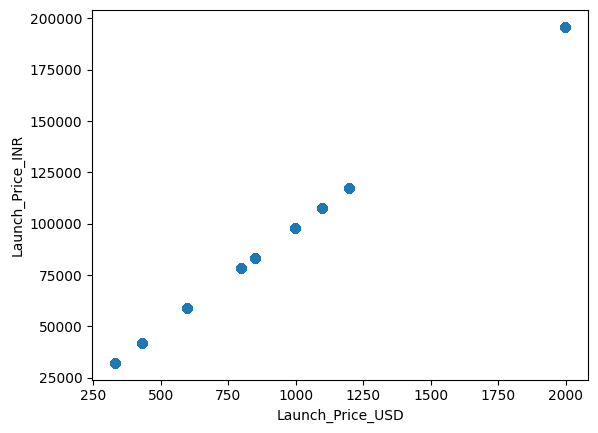

In [24]:
plt.scatter(df['Launch_Price_USD'], df['Launch_Price_INR'])
plt.xlabel('Launch_Price_USD')
plt.ylabel('Launch_Price_INR')
plt.show()

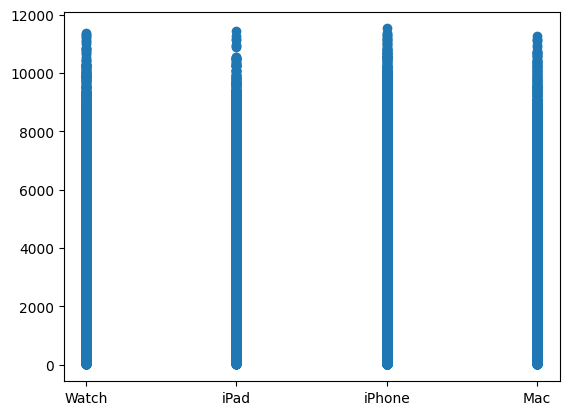

In [25]:
plt.scatter(df['Product_Category'], df['Reviews_Count'])
plt.show()

In [26]:
avg_rating_by_platform = df.groupby('Platform')['Rating'].mean()

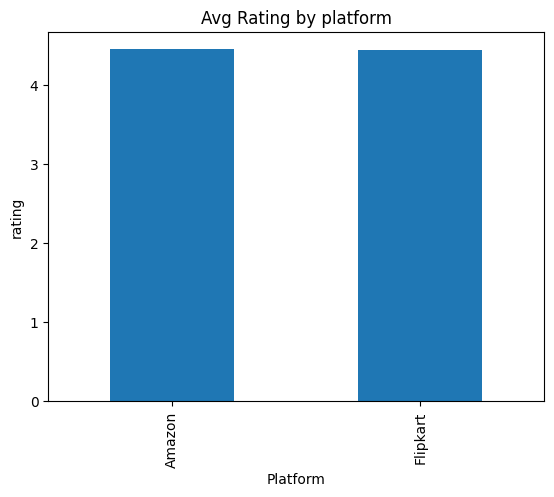

In [27]:
avg_rating_by_platform.plot(kind = 'bar')
plt.title("Avg Rating by platform")
plt.ylabel('rating')
plt.show()

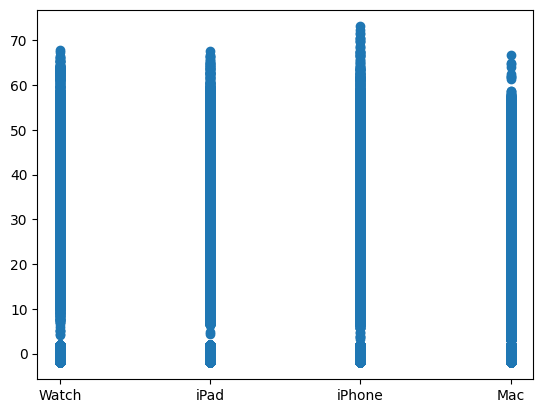

In [28]:
plt.scatter(df['Product_Category'], df['Discount_Pct'])
plt.show()

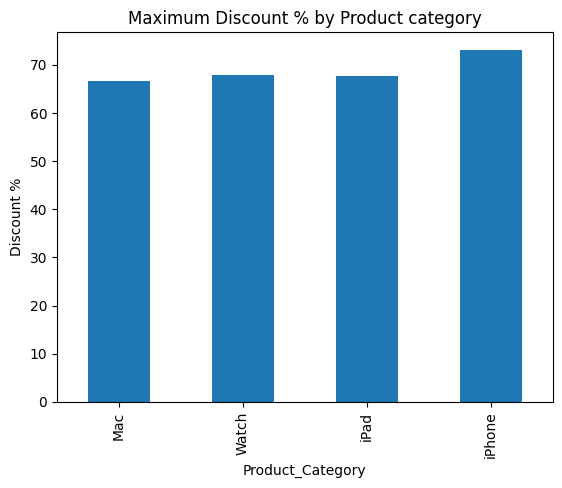

In [29]:
max_discount_pct_by_category = df.groupby('Product_Category')['Discount_Pct'].max()

max_discount_pct_by_category.plot(kind = 'bar')
plt.title('Maximum Discount % by Product category')
plt.ylabel('Discount %')
plt.show()

In [30]:
print(df.groupby('Product_Category')[['Rating', 'Current_Price_INR', 'Reviews_Count']].mean())

                    Rating  Current_Price_INR  Reviews_Count
Product_Category                                            
Mac               4.450461      131766.935548    2284.959101
Watch             4.448066       37983.284920    2380.098685
iPad              4.449916       54633.857522    2808.002254
iPhone            4.451240       72370.861505    2280.149883


#### 2.Data preprocessing

##### 2.1 Handling missing values

In [32]:
df.isnull().sum()

Date                     0
Platform                 0
Product_Category         0
Model_Name               0
Condition                0
Launch_Price_USD         0
Launch_Price_INR         0
Current_Price_USD        0
Current_Price_INR        0
Discount_Pct             0
Sale_Event           73351
Stock_Status             0
Rating                   0
Reviews_Count            0
dtype: int64

In [36]:
missing_percentage = (df.isnull().sum() / len(df)) *100
print(missing_percentage.sort_values(ascending = False))

Sale_Event           91.68875
Date                  0.00000
Platform              0.00000
Product_Category      0.00000
Model_Name            0.00000
Condition             0.00000
Launch_Price_USD      0.00000
Launch_Price_INR      0.00000
Current_Price_USD     0.00000
Current_Price_INR     0.00000
Discount_Pct          0.00000
Stock_Status          0.00000
Rating                0.00000
Reviews_Count         0.00000
dtype: float64


#### If the column having more than 90% of missing values then it is better to remove it

In [37]:
df_clean = df.copy(deep = True)

In [38]:
df_clean.drop(columns = ['Sale_Event'], inplace = True)

In [39]:
df_clean.isnull().sum()

Date                 0
Platform             0
Product_Category     0
Model_Name           0
Condition            0
Launch_Price_USD     0
Launch_Price_INR     0
Current_Price_USD    0
Current_Price_INR    0
Discount_Pct         0
Stock_Status         0
Rating               0
Reviews_Count        0
dtype: int64

##### 2.2 Handling duplicate values

In [48]:
df_clean[df_clean.duplicated()]

,Date,Platform,Product_Category,Model_Name,Condition,Launch_Price_USD,Launch_Price_INR,Current_Price_USD,Current_Price_INR,Discount_Pct,Stock_Status,Rating,Reviews_Count


##### 2.3 Handling outliers

In [55]:
outliers = []
for col in num_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    count = ((df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)).sum()

    outliers.append({'column':col, 'count':count})

outliers_summary = pd.DataFrame(outliers)
print(outliers_summary)

              column  count
0   Launch_Price_USD      0
1   Launch_Price_INR      0
2  Current_Price_USD   5076
3  Current_Price_INR   5110
4       Discount_Pct      0
5             Rating      0
6      Reviews_Count   2628


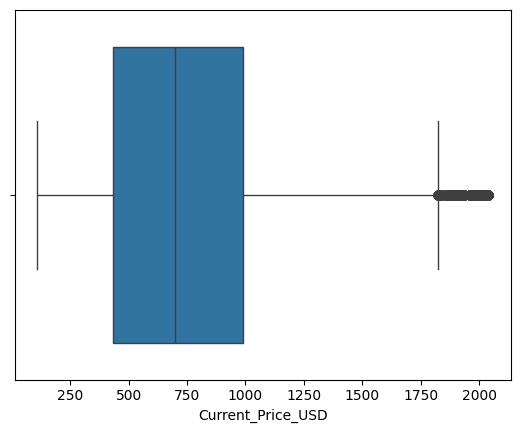

In [59]:
sns.boxplot(x = df_clean.Current_Price_USD)
plt.show()

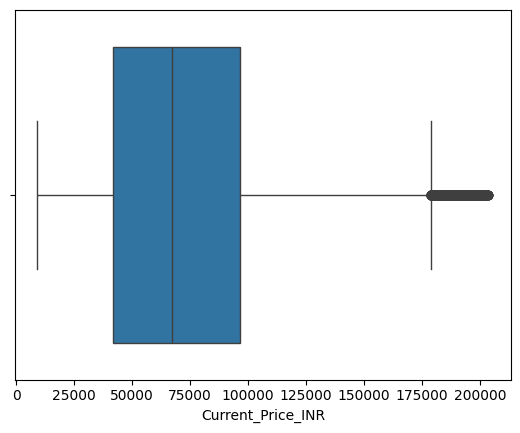

In [61]:
sns.boxplot(x = df_clean.Current_Price_INR)
plt.show()

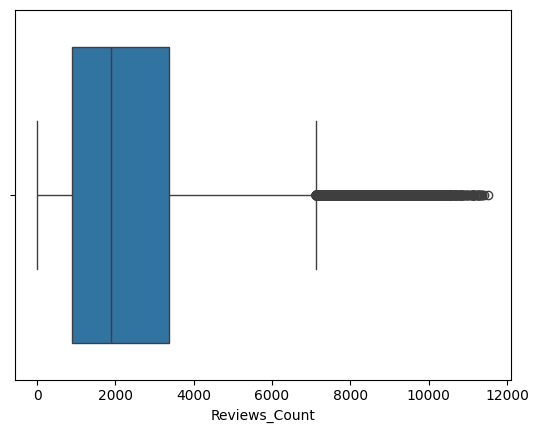

In [63]:
sns.boxplot(x = df_clean.Reviews_Count)
plt.show()

#### I observed that the above three columns having outliers which is real meaning outliers so i should keep this columns

##### 2.4 Encode categorical variables

In [65]:
cat_cols = df_clean.select_dtypes(include = 'object').columns

In [66]:
cat_cols

Index(['Platform', 'Product_Category', 'Model_Name', 'Condition',
       'Stock_Status'],
      dtype='object')

In [70]:
for col in cat_cols:
    print(f"\ncolumn:{col}\n", df_clean[col].unique())


column:Platform
 ['Flipkart' 'Amazon']

column:Product_Category
 ['Watch' 'iPad' 'iPhone' 'Mac']

column:Model_Name
 ['Apple Watch Series 6 (44mm)' 'iPad Air (4th Gen) 64GB' 'iPhone 12 64GB'
 'iPhone 12 Pro 128GB' 'MacBook Air M1 256GB'
 'iPad Pro 11-inch (M1) 128GB' 'iPhone 13 128GB' 'iPhone 13 Pro Max 256GB'
 'iPad (9th Gen) 64GB' 'Apple Watch Series 7 (45mm)'
 'MacBook Pro 14-inch M1 Pro 512GB' 'iPad Air (5th Gen) 64GB'
 'MacBook Air M2 256GB' 'Apple Watch Series 8 (45mm)' 'iPhone 14 128GB'
 'iPhone 14 Pro 128GB' 'Apple Watch Ultra' 'iPad Pro 12.9-inch (M2) 256GB'
 'MacBook Pro 14-inch M2 Pro 512GB' 'Apple Watch Series 9 (45mm)'
 'Apple Watch Ultra 2' 'iPhone 15 128GB' 'iPhone 15 Pro Max 256GB'
 'MacBook Pro 14-inch M3 Pro 512GB' 'MacBook Air M3 256GB'
 'iPad Pro 11-inch (M4) 256GB' 'iPhone 16 128GB' 'iPhone 16 Pro 256GB'
 'Apple Watch Series X (45mm)' 'MacBook Pro 14-inch M4 Pro 512GB'
 'iPhone 17 128GB']

column:Condition
 ['New' 'Renewed/Refurbished']

column:Stock_Status
 ['In 

In [72]:
df_clean.Model_Name.nunique()

31

In [73]:
print(df_clean['Rating'].describe())
print(df_clean['Rating'].value_counts().sort_index())

count    80000.000000
mean         4.450099
std          0.269782
min          3.800000
25%          4.300000
50%          4.400000
75%          4.700000
max          4.900000
Name: Rating, dtype: float64
Rating
3.8     1411
3.9     2878
4.0     2868
4.1     2905
4.2     7111
4.3    11475
4.4    11411
4.5     9942
4.6     8437
4.7     8578
4.8     8651
4.9     4333
Name: count, dtype: int64


##### I observed that removing model_name column might be a good choice because if i encode this column it will create 30 more columns and might be not useful anymore of this column i think

In [74]:
df_clean.drop(columns = ['Model_Name'], inplace = True)

In [79]:
df_clean = pd.get_dummies(df_clean, columns = ['Platform'], drop_first=True)

In [80]:
df_clean = pd.get_dummies(df_clean, columns = ['Product_Category'], drop_first=True)

In [81]:
df_clean = pd.get_dummies(df_clean, columns = ['Condition'], drop_first=True)

In [82]:
df_clean = pd.get_dummies(df_clean, columns = ['Stock_Status'], drop_first=True)

In [83]:
df_clean.head(2)

,Date,Launch_Price_USD,Launch_Price_INR,Current_Price_USD,Current_Price_INR,Discount_Pct,Rating,Reviews_Count,Platform_Flipkart,Product_Category_Watch,Product_Category_iPad,Product_Category_iPhone,Condition_Renewed/Refurbished,Stock_Status_Low Stock,Stock_Status_Out of Stock
0,2020-09-19,429,42042,435.81,43322.41,-1.6,4.7,40,True,True,False,False,False,False,False
1,2020-09-20,429,42042,436.49,42320.43,-1.7,4.6,84,True,True,False,False,False,False,True


#### 3. Feature Engineering 

##### 3.1 Check Multicollenearity

###### 3.1.1 Using Heatmap

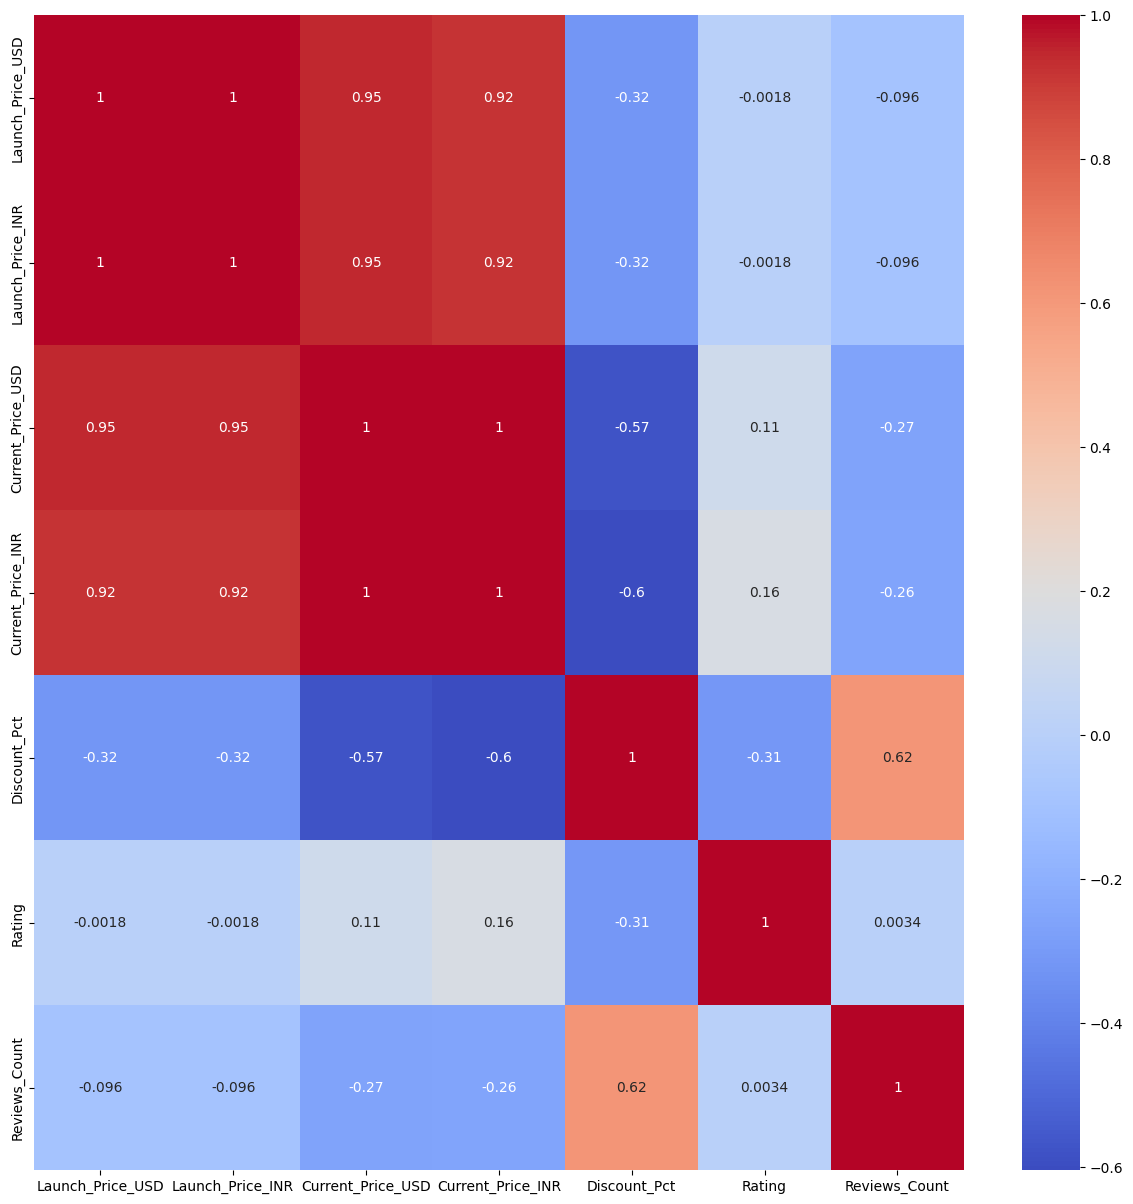

In [86]:
corr = df_clean.select_dtypes(include = 'number').corr()

plt.figure(figsize=(15, 15))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

#### Here i saw that 3-4 columns are highly correlated each other

###### 3.1.2 Using VIF

In [98]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df_clean.drop(['Date','Rating', 'Launch_Price_USD','Current_Price_USD', 'Launch_Price_INR'] , axis = 1)
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)
vif = pd.DataFrame()
vif['Feature'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) 
              for i in range(X.shape[1])]

print(vif)

                         Feature       VIF
0              Current_Price_INR  2.111860
1                   Discount_Pct  8.610326
2                  Reviews_Count  5.342538
3              Platform_Flipkart  1.961989
4         Product_Category_Watch  1.636370
5          Product_Category_iPad  1.564379
6        Product_Category_iPhone  1.809601
7  Condition_Renewed/Refurbished  2.282656
8         Stock_Status_Low Stock  1.275462
9      Stock_Status_Out of Stock  1.354593


In [99]:
df_clean['Year'] = df_clean.Date.dt.year
df_clean['Month'] = df_clean.Date.dt.month
df_clean['Day'] = df_clean.Date.dt.day

In [100]:
df_clean.drop(columns = ['Date'], inplace = True)

In [101]:
df_clean.drop(columns = ['Launch_Price_USD','Current_Price_USD', 'Launch_Price_INR'], inplace = True)

In [102]:
df_clean.columns

Index(['Current_Price_INR', 'Discount_Pct', 'Rating', 'Reviews_Count',
       'Platform_Flipkart', 'Product_Category_Watch', 'Product_Category_iPad',
       'Product_Category_iPhone', 'Condition_Renewed/Refurbished',
       'Stock_Status_Low Stock', 'Stock_Status_Out of Stock', 'Year', 'Month',
       'Day'],
      dtype='object')

#### 4. Train Test split

In [104]:
from sklearn.model_selection import train_test_split

X = df_clean.drop('Rating', axis = 1)
y = df_clean['Rating']

In [105]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### Feature Importance

In [109]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X, y)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [119]:
importance = pd.DataFrame({
    'Feature':X.columns,
    'Importance':rf.feature_importances_
})

In [124]:
importance.sort_values(by = 'Importance', ascending=False)

,Feature,Importance
7,Condition_Renewed/Refurbished,0.414210
2,Reviews_Count,0.142019
0,Current_Price_INR,0.135524
1,Discount_Pct,0.103004
12,Day,0.081684
11,Month,0.043831
10,Year,0.029376
3,Platform_Flipkart,0.014795
9,Stock_Status_Out of Stock,0.009833
8,Stock_Status_Low Stock,0.008772


#### 5. Feature Scaling

### I keep a seperate dataset for scaling and a seperate for tree based models

In [128]:
df_scaling = df_clean.copy(deep = True)

In [129]:
X = df_scaling.drop('Rating', axis = 1)
y = df_scaling['Rating']

In [130]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [131]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#### 6.Model Building

In [136]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

In [140]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = mse ** 0.5

r2 = r2_score(y_test, y_pred)

In [142]:
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 score:", r2)

MAE: 0.17894694819762522
MSE: 0.04280617831460015
RMSE: 0.20689654012235234
R2 score: 0.4071430111464184


#### 7.Model Building for Tree based models without scaling

In [143]:
X = df_clean.drop('Rating', axis = 1)
y = df_clean['Rating']

In [144]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [155]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor()

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

In [156]:
mae_dt = mean_absolute_error(y_test, y_pred_dt)

mse_dt = mean_squared_error(y_test, y_pred_dt)

rmse_dt = mse ** 0.5

r2_dt = r2_score(y_test, y_pred_dt)

In [157]:
print("MAE:", mae_dt)
print("MSE:", mse_dt)
print("RMSE:", rmse_dt)
print("R2 score:", r2_dt)

MAE: 0.24016250000000003
MSE: 0.08794000000000002
RMSE: 0.21201713845819165
R2 score: -0.21795137180003055


In [149]:
rf = RandomForestRegressor()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [151]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)

mse_rf = mean_squared_error(y_test, y_pred_rf)

rmse_rf = mse ** 0.5

r2_rf = r2_score(y_test, y_pred_rf)

In [158]:
print("MAE:", mae_rf)
print("MSE:", mse_rf)
print("RMSE:", rmse_rf)
print("R2 score:", r2_rf)

MAE: 0.18092249999999999
MSE: 0.044951267
RMSE: 0.21201713845819165
R2 score: 0.37743396285195085


In [160]:
!pip install xgboost

   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.3/69.5 MB ? eta -:--:--
   ---------------------------------------- 0.8/69.5 MB 2.0 MB/s eta 0:00:35
    --------------------------------------- 1.0/69.5 MB 2.1 MB/s eta 0:00:34
    --------------------------------------- 1.6/69.5 MB 2.2 MB/s eta 0:00:32
   - -------------------------------------- 1.8/69.5 MB 1.8 MB/s eta 0:00:38
   - -------------------------------------- 2.4/69.5 MB 1.9 MB/s eta 0:00:35
   - -------------------------------------- 2.9/69.5 MB 2.1 MB/s eta 0:00:32
   -- ------------------------------------- 3.7/69.5 MB 2.4 MB/s eta 0:00:28
   -- ------------------------------------- 4.7/69.5 MB 2.6 MB/s eta 0:00:26
   --- ------------------------------------ 5.2/69.5 MB 2.6 MB/s eta 0:00:25
   --- ------------------------------------ 6.0/69.5 MB 2.7 MB/s eta 0:00:24
   --- -------------

In [163]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor()

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

In [164]:
r2_xgb = r2_score(y_test, y_pred_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)

In [165]:
print("R² Score :", r2_xgb)
print("MAE      :", mae_xgb)
print("MSE      :", mse_xgb)

R² Score : 0.3845886377250707
MAE      : 0.18047641263008113
MSE      : 0.04443467649982899
